# Imports

In [19]:
import gc
import time
import itertools

import numpy as np
import pandas as pd
import pywt
from scipy.stats import ks_2samp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, log_loss

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset

from pytorch_tabnet.tab_model import TabNetClassifier

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools


# WT-CNN-TF

## Data Loader


In [3]:
# ==========================================================
# CAMADA 1: PROCESSAMENTO DE DADOS (ETL & ENCODING)
# ==========================================================

class LoanDataLoader:
    """
    Classe responsável pelo carregamento bruto e limpeza inicial dos dados tabulares.
    Foca em otimização de memória RAM através de downcasting e remoção de redundâncias.
    """

    def __init__(self, filepath, target_col):
        self.filepath = filepath
        self.target_col = target_col
        self.scaler = StandardScaler()

    def load_and_clean(self):
        """
        Lê o arquivo CSV, remove IDs, aplica downcasting numérico e encoding categórico.

        Returns:
            tuple: (X (numpy.ndarray), y (numpy.ndarray)) contendo as features e o alvo.
        """

        # 1. Carrega os dados
        print("Lendo CSV...")
        df = pd.read_csv(self.filepath)

        # 2. Proteção contra explosão de memória: Remove colunas de ID
        # Identifica colunas que tenham 'id' no nome (ex: 'client_id', 'loan_id')
        colunas_para_remover = [col for col in df.columns if 'id' in col.lower()]
        if colunas_para_remover:
            print(f"Removendo colunas de identificação para evitar estouro de RAM: {colunas_para_remover}")
            df = df.drop(columns=colunas_para_remover)

        # 3. Downcasting inicial: reduz o tamanho dos números na RAM
        print("Otimizando tipos de dados (Downcasting)...")
        cols_float = df.select_dtypes(include=['float64']).columns
        df[cols_float] = df[cols_float].astype(np.float32)

        cols_int = df.select_dtypes(include=['int64']).columns
        df[cols_int] = df[cols_int].astype(np.int32)

        # 4. Converte variáveis categóricas (texto) em números
        print("Aplicando One-Hot Encoding (get_dummies)...")
        df = pd.get_dummies(df, drop_first=True)

        # O get_dummies nas versões mais novas do pandas retorna True/False.
        # Vamos garantir que vire tudo número (float32) para a rede neural.
        df = df.astype(np.float32)

        # 5. Separa Features (X) e Target (y)
        X = df.drop(self.target_col, axis=1).values
        y = df[self.target_col].values

        return X, y

    def scale_data(self, X):
        return self.scaler.fit_transform(X)

## WT

In [4]:
# ==========================================================
# CAMADA 2: FEATURE ENGINEERING (WAVELET TRANSFORM)
# ==========================================================

class WaveletLoanDataset(Dataset):
    """
    Dataset customizado PyTorch que aplica a Transformada Discreta de Wavelet (DWT).
    Os coeficientes são pré-computados para acelerar o treinamento da CNN.
    """

    def __init__(self, X, y, wavelet='db4', level=3):
        """
        Inicializa o dataset e pré-calcula as transformadas.

        Args:
            X (numpy.ndarray): Features originais.
            y (numpy.ndarray): Target labels.
            wavelet (str): Família da wavelet (ex: 'db4').
            level (int): Nível de decomposição.
        """

        self.wavelet = wavelet
        self.level = level

        # Lista para armazenar as matrizes pré-processadas
        X_processed = []

        for i in range(len(X)):
            signal = X[i]
            # Extrai os coeficientes de aproximação e detalhe
            coeffs = pywt.wavedec(signal, self.wavelet, level=self.level)

            # Achata todos os arrays num único vetor contínuo
            features = np.concatenate(coeffs, axis=-1)
            X_processed.append(features)

        # O unsqueeze(1) adiciona a dimensão do canal (Batch, 1, Seq_Len) para a CNN
        self.X_tensor = torch.tensor(np.array(X_processed), dtype=torch.float32).unsqueeze(1)

        # Garante o formato [Batch, 1] do target para não dar problemas com o BCELoss
        self.y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        """Returns: int: Quantidade total de amostras."""
        return len(self.y_tensor)

    def __getitem__(self, idx):
        """
        Retorna um par de tensores (feature, label).

        Returns:
            tuple: (torch.Tensor, torch.Tensor)
        """
        # Agora a rede neural pega os dados instantaneamente sem fazer cálculos matemáticos!
        return self.X_tensor[idx], self.y_tensor[idx]

## Model Architeture

In [5]:
# ==========================================================
# CAMADA 3: ARQUITETURA DO MODELO HÍBRIDO (CNN + TRANSFORMER)
# ==========================================================

class CNNBlock(nn.Module):
    """
    Bloco Convolucional dinâmico para extração de padrões espaciais/frequenciais
    nos coeficientes da Wavelet.
    """
    def __init__(self, in_channels=1, channels=[32, 64, 128, 256], kernel_size=3, dropouts=[0.25, 0.25, 0.5, 0.5]):
        super().__init__()
        layers = []
        current_in = in_channels

        # Constrói as camadas convolucionais dinamicamente
        for out_channels, drop_rate in zip(channels, dropouts):
            layers.extend([
                nn.Conv1d(current_in, out_channels, kernel_size=kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2, stride=2),
                nn.Dropout(drop_rate)
            ])
            current_in = out_channels

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """Returns: torch.Tensor: Features extraídas pela CNN."""
        return self.network(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: (Batch, Seq, Features)
        x = x + self.pe[:, :x.size(1), :]
        return x

class TransformerBlock(nn.Module):
    """
    Módulo de Atenção (Transformer) para capturar dependências de longo alcance
    entre as features extraídas pela CNN.
    """
    def __init__(self, d_model=256, nhead=8, num_encoder_layers=6, num_decoder_layers=6, dropout=0.1):
        super().__init__()

        self.pos_encoder = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dropout=dropout,
            batch_first=True
        )

        self.tgt_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.xavier_uniform_(self.tgt_token)

    def forward(self, x):
        """Returns: torch.Tensor: Vetor de contexto (embedding) do Transformer."""
        batch_size = x.size(0)
        src = self.pos_encoder(x)
        tgt = self.tgt_token.expand(batch_size, -1, -1)
        out = self.transformer(src=src, tgt=tgt)
        out = out.squeeze(1)

        return out

class HybridRiskPredictor(nn.Module):
    """
    Classe que une Wavelet-CNN e Transformer para predição final de risco.
    """
    def __init__(self, cnn_params: dict, tf_params: dict, clf_hidden=64):
        super().__init__()
        self.cnn = CNNBlock(**cnn_params)
        self.transformer = TransformerBlock(**tf_params)

        d_model = tf_params.get('d_model', 256)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, clf_hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(clf_hidden, 1)
        )

    def forward(self, x):
        """Returns: torch.Tensor: Logits da predição (binária)."""
        x = self.cnn(x)
        x = x.permute(0, 2, 1) # Adapta (Batch, Seq, Features) para o Transformer
        x = self.transformer(x)
        return self.classifier(x)


# ==========================================================
# CAMADA 4: WRAPPER DE TREINAMENTO E VALIDAÇÃO
# ==========================================================
class HybridCreditModel:
    """
    Interface de alto nível para gerenciar o ciclo de vida do modelo (fit/predict).
    Encapsula o otimizador, função de perda e métricas de desempenho.
    """
    def __init__(self, cnn_params={}, tf_params={}, clf_hidden=64, lr=0.0001, device=None):
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = HybridRiskPredictor(
            cnn_params=cnn_params,
            tf_params=tf_params,
            clf_hidden=clf_hidden
        ).to(self.device)

        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Dicionário para guardar o histórico e gerar os gráficos depois
        self.history = {'loss': [], 'valid_logloss': [], 'valid_auc': [], 'fpr': [], 'tpr': []}

    def train(self, train_loader, valid_loader=None, epochs=15):
        """
        Executa o loop de treinamento e validação. Imprime progresso por época.

        Args:
            train_loader (DataLoader): Dados de treino.
            valid_loader (DataLoader): Dados de validação.
            epochs (int): Número de iterações.
        """
        print("\nIniciando o Treinamento da Rede Híbrida...")

        for epoch in range(epochs):
            start_time = time.time() # Começa a contar o tempo

            self.model.train()
            train_loss = 0.0

            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                batch_y = batch_y.view(-1, 1)

                self.optimizer.zero_grad()
                logits = self.model(batch_X)
                loss = self.criterion(logits, batch_y)

                loss.backward()
                self.optimizer.step()
                train_loss += loss.item()

            train_loss_avg = train_loss / len(train_loader)

            if valid_loader:
                self.model.eval()
                valid_loss = 0.0
                all_targets = []
                all_probs = []

                with torch.no_grad():
                    for batch_X, batch_y in valid_loader:
                        batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                        batch_y_view = batch_y.view(-1, 1)

                        logits = self.model(batch_X)
                        loss = self.criterion(logits, batch_y_view)
                        valid_loss += loss.item()

                        # Calcula probabilidades para o AUC
                        probs = torch.sigmoid(logits).cpu().numpy()
                        targets = batch_y.cpu().numpy()

                        all_probs.extend(probs)
                        all_targets.extend(targets)

                valid_loss_avg = valid_loss / len(valid_loader)

                # Calcula a métrica AUC
                valid_auc = roc_auc_score(all_targets, all_probs)
                fpr, tpr, limiares = roc_curve(all_targets, all_probs)

                # Guarda no histórico
                self.history['loss'].append(train_loss_avg)
                self.history['valid_logloss'].append(valid_loss_avg)
                self.history['valid_auc'].append(valid_auc)
                self.history['fpr'].append(fpr)
                self.history['tpr'].append(tpr)

                # Formatação exata pedida (O BCE Loss é matematicamente igual ao LogLoss)
                elapsed_time = time.time() - start_time
                print(f"epoch {epoch+1:<2} | loss: {train_loss_avg:.5f} | valid_auc: {valid_auc:.5f} | valid_logloss: {valid_loss_avg:.5f} |  {elapsed_time:.2f}s")

    def predict_default_proba(self, test_loader):
        """
        Calcula as probabilidades de inadimplência (0 a 1).

        Args:
            test_loader (DataLoader): Dados de teste.
        Returns:
            np.ndarray: Array de probabilidades preditas.
        """
        self.model.eval()
        all_probs = []
        with torch.no_grad():
            for batch_X, _ in test_loader:
                batch_X = batch_X.to(self.device)
                logits = self.model(batch_X)
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.extend(probs)
        return np.array(all_probs).flatten()

class HybridDataProcessor:
    """
    Processador de dados inspirado no Modelo_Diego, mas adaptado
    para preparar tensores para a Transformada Wavelet e CNN.
    """
    def __init__(self, filepath):
        self.filepath = filepath
        self.TARGET = 'loan_status'

        # Variáveis Categóricas (precisam de One-Hot Encoding)
        self.CATEGORICALS = [
            'occupation_status', 'product_type', 'loan_intent'
        ]

        # Variáveis Numéricas (precisam de StandardScaler)
        self.NUMERICALS = [
            'age', 'years_employed', 'annual_income',
            'credit_score', 'credit_history_years', 'savings_assets',
            'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs',
            'derogatory_marks', 'loan_amount', 'interest_rate',
            'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio'
        ]

        self.scaler = StandardScaler()

    def load_and_preprocess(self):
        print("Carregando e processando os dados...")
        df = pd.read_csv(self.filepath)

        # 1. Guardar o valor real dos empréstimos para a Regra de Negócio (Solução do Erro 3)
        loan_amounts_reais = df['loan_amount'].values

        # 2. Separar o Alvo (Target)
        y = df[self.TARGET].values

        # 3. Processar Categóricas (One-Hot Encoding)
        # Transforma, por exemplo, 'loan_intent' em várias colunas (intent_A, intent_B...) contendo 0 ou 1
        df_cat = pd.get_dummies(df[self.CATEGORICALS], columns=self.CATEGORICALS, drop_first=True)
        df_cat = df_cat.astype(np.float32)

        # 4. Processar Numéricas (Z-Score Normalization)
        df_num = df[self.NUMERICALS].copy()
        df_num[self.NUMERICALS] = self.scaler.fit_transform(df_num[self.NUMERICALS])
        df_num = df_num.astype(np.float32)

        # 5. Juntar tudo numa única matriz de características (X)
        df_final = pd.concat([df_num, df_cat], axis=1)
        X = df_final.astype(np.float32).values
        y = y.astype(np.float32)

        print(f"Dados processados! Shape final de X: {X.shape}")
        return X, y, loan_amounts_reais

class HybridGridSearch:
    """
    Orquestrador automático para testar múltiplas combinações de hiperparâmetros.
    Treina todas as arquiteturas fornecidas e devolve o melhor modelo com base no AUC.
    """
    def __init__(self, X_train, y_train, X_test, y_test, batch_size=256):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.batch_size = batch_size

        self.tabela_resultados = []
        self.modelos_treinados = {}

    def executar(self, opcoes_wt, opcoes_cnn, opcoes_tf, opcoes_lr, opcoes_epochs):
        print("\nMontando a Bateria de Testes (Grid Search)...")

        # Cria todas as combinações possíveis (Produto Cartesiano)
        todas_combinacoes = list(itertools.product(opcoes_wt, opcoes_cnn, opcoes_tf, opcoes_lr, opcoes_epochs))

        print(f"Foram geradas {len(todas_combinacoes)} arquiteturas únicas para testar!")
        print("Aviso: Isto pode demorar algum tempo. Sente-se e relaxe...\n")

        for i, config in enumerate(todas_combinacoes):
            wt_lvl, cnn_conf, tf_conf, lr, epochs = config
            ultimo_canal_cnn = cnn_conf[0][-1]

            nome_arq = f"Mod_{i+1}_WT{wt_lvl}_CNN{len(cnn_conf[0])}_TF{tf_conf[2]}_LR{lr}"
            print(f"\n{'='*60}")
            print(f" TREINANDO [{i+1}/{len(todas_combinacoes)}]: {nome_arq}")
            print(f"{'='*60}")

            # 1. Prepara os Datasets Dinâmicos (recalcula a WT se o nível mudar)
            train_dataset = WaveletLoanDataset(self.X_train, self.y_train, wavelet='db4', level=wt_lvl)
            test_dataset = WaveletLoanDataset(self.X_test, self.y_test, wavelet='db4', level=wt_lvl)

            train_dl = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2, pin_memory=True)
            test_dl = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2, pin_memory=True)

            # 2. Configura os Dicionários da Arquitetura
            cnn_params = {
                'in_channels': 1,
                'channels': cnn_conf[0],
                'dropouts': cnn_conf[1],
                'kernel_size': cnn_conf[2]
            }

            tf_params = {
                'd_model': ultimo_canal_cnn, # Força o encaixe perfeito CNN -> TF
                'nhead': tf_conf[1],
                'num_encoder_layers': tf_conf[2],
                'num_decoder_layers': tf_conf[2],
                'dropout': tf_conf[3]
            }

            # 3. Treina o Modelo
            model_test = HybridCreditModel(cnn_params=cnn_params, tf_params=tf_params, clf_hidden=64, lr=lr)
            model_test.train(train_dl, valid_loader=test_dl, epochs=epochs)

            self.modelos_treinados[nome_arq] = model_test

            # 4. Extrai as Métricas
            historico = model_test.history
            melhor_auc = max(historico['valid_auc'])
            fpr, tpr = historico['fpr'], historico['tpr']
            epoca_ideal = historico['valid_auc'].index(melhor_auc)
            loss_na_epoca_ideal = historico['valid_logloss'][epoca_ideal]

            self.tabela_resultados.append({
                'Arquitetura': nome_arq,
                'WT': wt_lvl,
                'Camadas CNN': len(cnn_conf[0]),
                'Kernel CNN': cnn_conf[2],
                'Camadas TF': tf_conf[2],
                'LR': lr,
                'Epocas': epochs,
                'Melhor AUC': round(melhor_auc, 4),
                'LogLoss': round(loss_na_epoca_ideal, 4),
                'FPR': fpr,
                'TPR': tpr,
            })

        # 5. Processa os Resultados Finais
        return self._gerar_relatorio_final()

    def _gerar_relatorio_final(self):
        print("\n\n" + "*"*60)
        print("RESULTADO FINAL DO GRID SEARCH")
        print("*"*60)

        df_comparacao = pd.DataFrame(self.tabela_resultados).sort_values(by='Melhor AUC', ascending=False)
        print(df_comparacao.to_string(index=False))

        nome_vencedor = df_comparacao.iloc[0]['Arquitetura']
        melhor_modelo = self.modelos_treinados[nome_vencedor]

        print(f"\nO modelo selecionado para as Regras de Negócio foi: {nome_vencedor}")

        return melhor_modelo, df_comparacao

# Tab Net

In [6]:
# ==========================================
# CAMADA 1: PROCESSAMENTO DE DADOS
# ==========================================
class RobustCreditDataProcessor:
    """
    Processador de dados tabulares (Stateful) para redes neurais.

    Esta classe garante a ausência de vazamento de dados (Data Leakage)
    armazenando as estatísticas do conjunto de treinamento e aplicando-as
    passivamente aos dados de validação/produção.
    """
    def __init__(self, target_col, categorical_cols, numerical_cols):
        self.target_col = target_col
        self.categorical_cols = categorical_cols
        self.numerical_cols = numerical_cols
        self.imputation_values = {}
        self.category_mappings = {}
        self.cat_idxs = []
        self.cat_dims = []

    def fit(self, df_train):
        """
        Aprende os parâmetros estatísticos exclusivamente da base de treino.

        Args:
            df_train (pd.DataFrame): DataFrame contendo apenas os dados de treinamento.
        """
        features = self.categorical_cols + self.numerical_cols

        for col in self.numerical_cols:
            self.imputation_values[col] = df_train[col].median()

        for idx, col in enumerate(features):
            if col in self.categorical_cols:
                unique_classes = df_train[col].dropna().unique().tolist()
                # Índice 0 reservado para valores OOV (Out Of Vocabulary)
                mapping = {val: i + 1 for i, val in enumerate(unique_classes)}
                self.category_mappings[col] = mapping
                self.cat_idxs.append(idx)
                self.cat_dims.append(len(unique_classes) + 1)

    def transform(self, df):
        """
        Aplica as transformações previamente aprendidas no método fit().

        Args:
            df (pd.DataFrame): DataFrame a ser processado (validação ou produção).

        Returns:
            tuple: (X (numpy.ndarray), y (numpy.ndarray ou None), lista_de_features)
        """
        df_processed = df.copy()
        features = self.categorical_cols + self.numerical_cols

        for col in self.numerical_cols:
            df_processed[col] = df_processed[col].fillna(self.imputation_values[col])

        for col in self.categorical_cols:
            mapping = self.category_mappings[col]
            df_processed[col] = df_processed[col].map(mapping).fillna(0).astype(int)

        X = df_processed[features].values
        y = df_processed[self.target_col].values if self.target_col in df_processed.columns else None

        return X, y, features

    def fit_transform(self, df_train):
        """ Executa fit e transform sequencialmente na base de treino. """
        self.fit(df_train)
        return self.transform(df_train)

# ==========================================
# CAMADA 2: MODELO TABNET
# ==========================================
class TabNetCreditModel:
    """
    Wrapper arquitetural para o modelo TabNet Classifier.

    Encapsula o framework PyTorch TabNet para classificação tabular,
    fornecendo métodos unificados de treino e predição de probabilidades.
    """
    def __init__(self, cat_idxs, cat_dims):
        """
        Inicializa a rede neural TabNet.

        Args:
            cat_idxs (list): Lista de índices das colunas categóricas.
            cat_dims (list): Lista com a cardinalidade (dimensões) de cada variável categórica.
        """

        self.cat_idxs = cat_idxs
        self.cat_dims = cat_dims
        self.tabela_resultados = []

    def standard_model(self):
        self.model = TabNetClassifier(
            cat_idxs=self.cat_idxs,
            cat_dims=self.cat_dims,
            cat_emb_dim=2,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=2e-2),
            scheduler_params={"step_size":10, "gamma":0.9},
            scheduler_fn=torch.optim.lr_scheduler.StepLR,
            mask_type='entmax'
        )

    def grid_search(self, X_train, y_train, X_valid, y_valid, param_grid):
        grid = ParameterGrid(param_grid)
        best_auc = 0
        best_params = None
        best_model = None

        print(f"\n[Grid Search] Iniciando busca em {len(grid)} combinações...")

        for i, params in enumerate(grid):
            # Condição para manter n_a igual a n_d (Recomendado pelo paper do TabNet)
            if 'n_d' in params and 'n_a' in params and params['n_d'] != params['n_a']:
                continue

            print(f"Testando combinação {i+1}/{len(grid)}: {params}")

            # Instancia um TabNet temporário com os novos hiperparâmetros
            current_model = TabNetClassifier(
                cat_idxs=self.cat_idxs,
                cat_dims=self.cat_dims,
                n_d=params.get('n_d', 8),
                n_a=params.get('n_a', 8),
                n_steps=params.get('n_steps', 3),
                gamma=params.get('gamma', 1.3),
                cat_emb_dim=2,
                optimizer_fn=torch.optim.Adam,
                optimizer_params=dict(lr=params.get('lr', 2e-2)),
                mask_type='entmax',
                verbose=0 # Para não poluir o log
            )

            # Treina rápido usando early stopping
            current_model.fit(
                X_train=X_train, y_train=y_train,
                eval_set=[(X_valid, y_valid)],
                eval_metric=['auc'],
                max_epochs=20, patience=10,
                batch_size=1024, virtual_batch_size=128
            )

            # Avalia
            preds = current_model.predict_proba(X_valid)[:, 1]
            auc = roc_auc_score(y_valid, preds)
            fpr, tpr, limiares = roc_curve(y_valid, preds)
            loss = log_loss(y_valid, preds)

            # Salva os modelos para graficos
            self.tabela_resultados.append({
                'Arquitetura': 'TabNet',
                'n_d / n_a': params.get('n_d', 8), # Tamanho da rede
                'n_steps': params.get('n_steps', 3), # Profundidade
                'gamma': params.get('gamma', 1.3),
                'LR': params.get('lr', 2e-2),
                'Melhor AUC': round(auc, 4),
                'LogLoss': round(loss, 4),
                'FPR': fpr,
                'TPR': tpr,
            })

            # Salva o melhor
            if auc > best_auc:
                best_auc = auc
                best_params = params
                best_model = current_model

        print(f"\n[Grid Search Concluído] Melhor AUC: {best_auc:.4f}")
        print(f"Melhores Parâmetros: {best_params}")

        # SUBSTITUI o modelo padrão pelo modelo treinado otimizado!
        self.model = best_model

    def train(self, X_train, y_train, X_valid, y_valid, max_epochs=50):
        """
        Treina a rede neural utilizando validação antecipada (Early Stopping).
        """
        print("\nTreinando TabNet sem vazamento de dados...")
        self.model.fit(
            X_train=X_train, y_train=y_train,
            eval_set=[(X_valid, y_valid)],
            eval_name=['valid'],
            eval_metric=['auc', 'logloss'],
            max_epochs=max_epochs, patience=10,
            batch_size=1024, virtual_batch_size=128
        )

    def predict_default_proba(self, X):
        """
        Retorna a probabilidade da classe positiva (Inadimplência = 1).
        """
        return self.model.predict_proba(X)[:, 1]

# Modelo de Decisão

In [7]:
# ==========================================================
# CAMADA 5: MOTOR DE DECISÃO FINANCEIRA (BUSINESS RULES)
# ==========================================================
class OptimizedDecisionEngine:
    """
    Motor de Decisão baseado em Esperança Matemática.

    Implementa a política de aprovação baseada na desigualdade:
    Lucro Esperado > 0  -->  p < r / (1 + r)
    """
    def __init__(self, interest_rate):
        self.interest_rate = interest_rate
        # p_max = r / (1 + r)
        self.max_tolerable_risk = interest_rate / (1 + interest_rate)

    def evaluate_applications(self, default_probabilities, loan_amounts):
        """
        Avalia um lote de predições e aplica a regra de negócio.

        Args:
            default_probabilities (np.ndarray): Array com as probabilidades 'p'.
            loan_amounts (np.ndarray): Array com os valores solicitados 'L'.

        Returns:
            tuple: (Máscara booleana de aprovados, Array de Lucro Esperado)
        """
        p = default_probabilities
        L = loan_amounts
        r = self.interest_rate

        approved_mask = p < self.max_tolerable_risk

        # E[Lucro] = (1 - p) * (L * r) - (p * L)
        expected_profits = (1 - p) * (L * r) - (p * L)

        return approved_mask, expected_profits

# Graficos e metricas


In [21]:
# ==========================================================
# CAMADA 6: MÉTRICAS E VISUALIZAÇÃO
# ==========================================================
class CreditVisualizer:
    """
    Gera relatórios visuais baseados nas predições matemáticas do modelo.
    """
    @staticmethod
    def plot_business_metrics(results_df, threshold, interest_rate):
        """
        Plota 3 gráficos essenciais para tomada de decisão financeira.
        """
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # 1. Distribuição de Probabilidades e Limiar de Risco
        sns.histplot(data=results_df, x='Probabilidade_Calote_Predita', bins=50,
                     hue='Decisao', multiple="stack", ax=axes[0], palette={'Aprovado': 'green', 'Reprovado': 'red'})
        axes[0].axvline(threshold, color='black', linestyle='--', linewidth=2,
                        label=f'Limiar Matemático: p_max = {threshold:.3f}')
        axes[0].set_title(r"Distribuição de Risco (Política: $p < \frac{r}{1+r}$)")
        axes[0].legend()

        # 2. Lucro Esperado vs Valor Solicitado
        sns.scatterplot(data=results_df, x='Valor_Solicitado', y='Lucro_Esperado',
                        hue='Decisao', alpha=0.6, ax=axes[1], palette={'Aprovado': 'green', 'Reprovado': 'red'})
        axes[1].axhline(0, color='black', linestyle='--', linewidth=2)
        axes[1].set_title(r"Esperança Matemática: $E[Lucro] = (1-p)(Lr) - pL$")
        axes[1].set_ylabel("Lucro Esperado ($)")

        # 3. Análise de Lucratividade Agrupada
        profit_summary = results_df.groupby('Decisao')['Lucro_Esperado'].sum().reset_index()
        sns.barplot(data=profit_summary, x='Decisao', y='Lucro_Esperado',
                    hue='Decisao', ax=axes[2], palette={'Aprovado': 'green', 'Reprovado': 'red'}, legend=False)
        axes[2].set_title(f"Balanço Projetado Total (Taxa: {interest_rate*100}%)")
        axes[2].set_ylabel("Soma do Lucro Esperado ($)")

        plt.tight_layout()
        plt.show()

class ComparadorModelos:
    """
    Classe executiva para visualização e comparação de performance
    entre o Modelo Híbrido (WT+CNN+TF) e o TabNet.
    """
    def __init__(self, history_hibrido=None, history_tabnet=None,
                 y_true=None, p_pred_hibrido=None, p_pred_tabnet=None):

        self.hist_hib = history_hibrido
        self.hist_tab = history_tabnet
        self.y_true = y_true
        self.p_hib = p_pred_hibrido
        self.p_tab = p_pred_tabnet

        # Paleta de Cores Corporativas (Baseada no seu plots.txt)
        self.cor_hib = '#1A5276'  # Azul Escuro (Para o Híbrido)
        self.cor_tab = '#C0392B'  # Vermelho Escuro (Para o TabNet)
        self.cor_base = '#AAB7B8' # Cinza Claro (Para referências)

    def _configurar_estilo_base(self, ax=None):
        """Função interna para limpar bordas e aplicar estilo minimalista."""
        sns.set_style("white")
        if ax:
            sns.despine(ax=ax, left=True, bottom=False)
            ax.grid(axis='y', linestyle=':', alpha=0.6)
        else:
            sns.despine(left=True, bottom=False)
            plt.grid(axis='y', linestyle=':', alpha=0.6)

    def plot_evolucao_loss(self, nome_arquivo=None):
        """Plota a evolução do Erro (Loss) na Validação para os dois modelos juntos."""
        if not self.hist_hib or not self.hist_tab:
            print("É necessário fornecer ambos os históricos para esta comparação.")
            return

        plt.figure(figsize=(12, 6), facecolor='white')
        self._configurar_estilo_base()

        # Função auxiliar à prova de falhas para extrair a Loss
        # Ignora o facto do TabNet ter um formato de histórico não-convencional
        def buscar_loss(historico):
            try:
                return historico['valid_logloss'] # Tenta o nome padrão da nossa rede
            except KeyError:
                try:
                    return historico['val_0_logloss'] # Tenta o nome padrão do TabNet
                except KeyError:
                    try:
                        return historico['loss'] # Tenta pegar pelo menos o treino
                    except KeyError:
                        return [] # Se nada funcionar, devolve vazio

        # Extraindo dados de Validação (LogLoss)
        loss_hib = buscar_loss(self.hist_hib)
        loss_tab = buscar_loss(self.hist_tab)

        epocas_hib = range(1, len(loss_hib) + 1)
        epocas_tab = range(1, len(loss_tab) + 1)

        plt.plot(epocas_hib, loss_hib, color=self.cor_hib, lw=3, label='Híbrido (WT+CNN+TF)')
        plt.plot(epocas_tab, loss_tab, color=self.cor_tab, lw=3, label='TabNet')

        plt.title('Convergência dos Modelos (Curva de Perda na Validação)\nComparação de estabilidade e velocidade de aprendizado',
                  fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

        plt.xlabel('Épocas (Epochs)', fontsize=12, fontweight='bold', color='#2C3E50')
        plt.ylabel('Erro LogLoss', fontsize=12, fontweight='bold', color='#2C3E50')
        plt.legend(frameon=True, fontsize=11, shadow=True)

        plt.tight_layout()
        if nome_arquivo:
            plt.savefig(nome_arquivo, dpi=300)
        plt.show()

    def plot_curvas_roc(self, nome_arquivo=None):
        """Plota as Curvas ROC de ambos os modelos no mesmo gráfico para fácil comparação."""
        if self.y_true is None or self.p_hib is None or self.p_tab is None:
            print("É necessário fornecer y_true e as predições de ambos os modelos.")
            return

        plt.figure(figsize=(10, 8), facecolor='white')
        self._configurar_estilo_base()

        # Cálculo ROC Híbrido
        fpr_hib, tpr_hib, _ = roc_curve(self.y_true, self.p_hib)
        auc_hib = auc(fpr_hib, tpr_hib)

        # Cálculo ROC TabNet
        fpr_tab, tpr_tab, _ = roc_curve(self.y_true, self.p_tab)
        auc_tab = auc(fpr_tab, tpr_tab)

        # Plot Híbrido
        plt.plot(fpr_hib, tpr_hib, color=self.cor_hib, lw=3,
                 label=f'Híbrido (AUC = {auc_hib:.4f})')
        # Plot TabNet
        plt.plot(fpr_tab, tpr_tab, color=self.cor_tab, lw=3,
                 label=f'TabNet (AUC = {auc_tab:.4f})')

        # Referência
        plt.plot([0, 1], [0, 1], color=self.cor_base, lw=2, linestyle='--', label='Aleatório')

        plt.fill_between(fpr_hib, tpr_hib, color="#1A5276", lw=3, alpha=0.1)

        plt.xlim([-0.01, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold', color='#2C3E50')
        plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12, fontweight='bold', color='#2C3E50')

        plt.title('Comparação de Performance (Curva ROC)\nCapacidade de separação entre Bons e Maus pagadores',
                  fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

        plt.legend(loc="lower right", frameon=True, fontsize=12, shadow=True)
        plt.tight_layout()
        if nome_arquivo:
            plt.savefig(nome_arquivo, dpi=300)
        plt.show()

    def _plotar_ks_individual(self, ax, p_pred, nome_modelo, cor_principal):
        """Função auxiliar para plotar o KS dentro de um subplot."""
        data = pd.DataFrame({'target': self.y_true, 'proba': p_pred})
        prob_bons = data[data['target'] == 1]['proba']
        prob_maus = data[data['target'] == 0]['proba']

        def ecdf(d):
            x = np.sort(d)
            y = np.arange(1, len(x) + 1) / len(x)
            return x, y

        x_bons, y_bons = ecdf(prob_bons)
        x_maus, y_maus = ecdf(prob_maus)
        ks_stat, _ = ks_2samp(prob_bons, prob_maus)

        ax.step(x_bons, y_bons, color=self.cor_base, lw=2.5, label='Bons', where='post')
        ax.step(x_maus, y_maus, color=cor_principal, lw=2.5, label='Maus', where='post')

        # Encontrando ponto KS
        idx_ks = np.argmax(np.abs(np.interp(x_maus, x_bons, y_bons) - y_maus))
        x_ks = x_maus[idx_ks]
        y_bons_ks = np.interp(x_ks, x_bons, y_bons)
        y_maus_ks = y_maus[idx_ks]

        ax.vlines(x_ks, y_bons_ks, y_maus_ks, color='#27AE60', linestyle='--', lw=2)
        ax.text(x_ks + 0.05, (y_bons_ks + y_maus_ks) / 2, f'KS: {ks_stat:.2f}',
                fontsize=14, color='#27AE60', fontweight='bold')

        ax.set_title(f'Estatística KS - {nome_modelo}', fontsize=14, fontweight='bold', color='#2C3E50')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.05])
        ax.legend(loc="upper left")
        self._configurar_estilo_base(ax)

    def plot_comparacao_ks(self, nome_arquivo=None):
        """Cria um painel lado a lado com a curva KS de ambos os modelos."""
        if self.y_true is None or self.p_hib is None or self.p_tab is None:
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

        self._plotar_ks_individual(ax1, self.p_hib, 'Modelo Híbrido', self.cor_hib)
        self._plotar_ks_individual(ax2, self.p_tab, 'Modelo TabNet', self.cor_tab)

        plt.tight_layout()
        if nome_arquivo:
            plt.savefig(nome_arquivo, dpi=300)
        plt.show()

    def plot_distribuicao_scores(self, nome_arquivo=None):
        """Plota a distribuição (histograma limpo) das predições de ambos os modelos."""
        if self.p_hib is None or self.p_tab is None:
            return

        # Aumentamos um pouco a largura para acomodar os dois gráficos perfeitamente
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')
        sns.set_style("white")

        # Função auxiliar para aplicar o seu visual limpo a cada subplot
        def formatar_histograma(ax, p_pred, cor_barras, titulo):
            # Criação do Histograma
            sns.histplot(p_pred, bins=20, color=cor_barras, ax=ax,
                         edgecolor='white', linewidth=1.5, alpha=0.8)

            # Adição dos Rótulos de Dados (Data Labels)
            for p in ax.patches:
                height = p.get_height()
                if height > 0: # Só adiciona se a barra tiver valor
                    ax.annotate(f'{int(height)}',
                                (p.get_x() + p.get_width() / 2., height),
                                ha='center', va='center',
                                xytext=(0, 9),
                                textcoords='offset points',
                                fontsize=11, fontweight='bold', color=cor_barras)

            # Remoção dos Eixos com valores (Y completo e bordas)
            ax.get_yaxis().set_visible(False)
            sns.despine(ax=ax, left=True, bottom=False)

            # Elementos Estratégicos (Linha de Corte)
            # Usei um tom de verde escuro/neutro para a linha de corte para não sumir no gráfico vermelho do TabNet
            cor_linha_corte = '#27AE60'
            ax.axvline(x=0.5, color=cor_linha_corte, linestyle='--', lw=2.5)
            ax.text(0.52, ax.get_ylim()[1]*0.9, 'Corte (50%)',
                     color=cor_linha_corte, fontweight='bold', fontsize=11)

            # Customização do Eixo X e Título do Subplot
            ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
            ax.set_xlabel('Score de Risco (0 = Baixo Risco | 1 = Alto Risco)',
                          fontsize=11, fontweight='bold', color='#2C3E50')

            # Ajuste fino de limites
            ax.set_xlim(0, 1)
            ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Dá mais 15% de espaço no topo para os números não cortarem

        # Aplicando a formatação aos dois gráficos
        formatar_histograma(ax1, self.p_hib, self.cor_hib, 'Modelo Híbrido (WT+CNN+TF)')
        formatar_histograma(ax2, self.p_tab, self.cor_tab, 'Modelo TabNet')

        # Título Geral da Figura
        plt.suptitle('Distribuição de Scores de Risco\nVolume de Clientes por Faixa de Probabilidade',
                     fontsize=18, fontweight='bold', color='#1A5276', y=1.05)

        plt.tight_layout()

        # Salva o gráfico com qualidade máxima se o nome do arquivo for passado
        if nome_arquivo:
            plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', transparent=False)

        plt.show()
    def plot_matriz_confusao(self, threshold=0.5, nome_arquivo=None):
        """Plota as Matrizes de Confusão de ambos os modelos lado a lado com Siglas."""
        if self.y_true is None or self.p_hib is None or self.p_tab is None:
            print("É necessário fornecer y_true e as predições de ambos os modelos.")
            return

        # Converte as probabilidades em classes binárias (0 ou 1) usando o threshold
        y_pred_hib = (self.p_hib >= threshold).astype(int)
        y_pred_tab = (self.p_tab >= threshold).astype(int)

        # Calcula a matriz usando o scikit-learn
        cm_hib = confusion_matrix(self.y_true, y_pred_hib)
        cm_tab = confusion_matrix(self.y_true, y_pred_tab)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
        sns.set_style("white")

        # Função auxiliar para formatar cada matriz individualmente
        def formatar_matriz(ax, cm, paleta_cores, titulo):
            # -----------------------------------------------------
            # NOVO: Criação dos rótulos com as siglas e os números
            # cm[0,0] = VN | cm[0,1] = FP
            # cm[1,0] = FN | cm[1,1] = VP
            # -----------------------------------------------------
            rotulos = np.array([
                [f"VN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
                [f"FN\n{cm[1,0]}", f"VP\n{cm[1,1]}"]
            ])

            # O parâmetro annot agora recebe a matriz de texto (rotulos) em vez de True
            # Mudamos o fmt para '' pois agora o conteúdo é texto e não apenas números inteiros ('d')
            sns.heatmap(cm, annot=rotulos, fmt='', cmap=paleta_cores, cbar=False, ax=ax,
                        annot_kws={'size': 16, 'weight': 'bold'})

            # Estilização dos eixos
            ax.set_title(titulo, fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
            ax.set_xlabel('Previsão do Modelo', fontsize=12, fontweight='bold', color='#2C3E50', labelpad=10)
            ax.set_ylabel('Valor Real', fontsize=12, fontweight='bold', color='#2C3E50', labelpad=10)

            # Ajuste dos rótulos
            ax.set_xticklabels(['Bom Pagador (0)', 'Mau Pagador (1)'], fontsize=11)
            ax.set_yticklabels(['Bom Pagador (0)', 'Mau Pagador (1)'], fontsize=11, rotation=0)

        # Aplicando a formatação aos dois modelos
        formatar_matriz(ax1, cm_hib, 'Blues', 'Modelo Híbrido (WT+CNN+TF)')
        formatar_matriz(ax2, cm_tab, 'Reds', 'Modelo TabNet')

        # Título Executivo Geral
        plt.suptitle(f'Matrizes de Confusão (Corte = {threshold*100:.0f}%)\nComparação de Acertos e Erros de Classificação',
                     fontsize=18, fontweight='bold', color='#1A5276', y=1.05)

        plt.tight_layout()

        # Salva o gráfico com qualidade máxima se o nome do arquivo for passado
        if nome_arquivo:
            plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight', transparent=False)

        plt.show()

# Main

In [9]:
# ------------------------------------------------------------------------------
# 1. PRÉ-PROCESSAMENTO TABULAR E SEPARAÇÃO DE DADOS (COMUM A TODOS OS MODELOS)
# ------------------------------------------------------------------------------
print("Iniciando a Fase 1: Processamento Tabular...")
arq = './content/loan_approval_dataset.csv'

# 1.A. Extração e Tratamento Unificado
processor = HybridDataProcessor(arq)
X_final, y_final, L_reais = processor.load_and_preprocess()

# 1.B. Consolidar os arrays num único DataFrame para um fatiamento
df = pd.DataFrame(X_final)
df['TARGET'] = y_final
df['L_reais'] = L_reais

# 1.C. Fazer o split de forma unificada (usando stratify para balancear)
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['TARGET']
)

# 1.D. Extrair os arrays de volta aos formatos originais (Numpy Arrays)
X_train = df_train.drop(columns=['TARGET', 'L_reais']).values
y_train = df_train['TARGET'].values
L_train = df_train['L_reais'].values

X_test = df_test.drop(columns=['TARGET', 'L_reais']).values
y_test = df_test['TARGET'].values
L_test = df_test['L_reais'].values

print("Dados processados e fatiados! Shape final de X_train:", X_train.shape)

Iniciando a Fase 1: Processamento Tabular...
Carregando e processando os dados...
Dados processados! Shape final de X: (50000, 24)
Dados processados e fatiados! Shape final de X_train: (40000, 24)


In [ ]:
# ==============================================================================
# MODELO 1: REDE HÍBRIDA (WAVELET + CNN + TRANSFORMER)
# ==============================================================================
print("\n" + "="*60)
print(" INICIANDO PIPELINE: WT + CNN + TRANSFORMER")
print("="*60)

# 2.A. Configuração do Grid Search Híbrido
# Passamos os arrays fatiados e o batch_size diretamente para a classe
model_wt_cnn_tf = HybridGridSearch(X_train, y_train, X_test, y_test, batch_size=256)

# Definimos as listas de hiperparâmetros que queremos testar
wt_levels_to_test = [1]
cnn_configs_to_test = [
    ([64, 128, 256], [0.3, 0.4, 0.5], 3)
]
tf_configs_to_test = [
    (256, 4, 2, 0.3)
]
learning_rates = [0.0005]
opcoes_epochs = [20]

# 2.B. Treinamento
# A função executar devolve o modelo vencedor e o DataFrame com os resultados
melhor_modelo_wt, df_resultados_wt = model_wt_cnn_tf.executar(
    wt_levels_to_test,
    cnn_configs_to_test,
    tf_configs_to_test,
    learning_rates,
    opcoes_epochs
)

# 2.C. Salvando os Resultados
df_resultados_wt.to_csv('./relatorios/resultados_wt_cnn_tf.csv', index=False)
print("Resultados do Grid Search da Rede Híbrida salvos no CSV!")


 INICIANDO PIPELINE: WT + CNN + TRANSFORMER

Montando a Bateria de Testes (Grid Search)...
Foram geradas 1 arquiteturas únicas para testar!
Aviso: Isto pode demorar algum tempo. Sente-se e relaxe...


 TREINANDO [1/1]: Mod_1_WT1_CNN3_TF2_LR0.0005

Iniciando o Treinamento da Rede Híbrida...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 1  | loss: 0.51092 | valid_auc: 0.91494 | valid_logloss: 0.40030 |  111.73s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 2  | loss: 0.40175 | valid_auc: 0.93853 | valid_logloss: 0.31535 |  106.53s


...

epoch 18 | loss: 0.29083 | valid_auc: 0.96296 | valid_logloss: 0.25421 |  120.92s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 19 | loss: 0.28965 | valid_auc: 0.96613 | valid_logloss: 0.24002 |  122.87s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 20 | loss: 0.30030 | valid_auc: 0.96518 | valid_logloss: 0.24118 |  122.69s


************************************************************
RESULTADO FINAL DO GRID SEARCH
************************************************************
                Arquitetura  WT  Camadas CNN  Kernel CNN  Camadas TF     LR  Epocas  Melhor AUC  LogLoss                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [ ]:
# ==============================================================================
# MODELO 3: TABNET
# ==============================================================================
print("\n" + "="*60)
print(" INICIANDO PIPELINE: TABNET")
print("="*60)

# 3.A. Instanciando o Modelo
# Como o HybridDataProcessor já transformou tudo numérico, o TabNet não
# precisa de cat_idxs. O X_train já é 100% Float/Int.
model_tab_net = TabNetCreditModel(cat_idxs=[], cat_dims=[])

# 3.B. Configuração do Grid Search TabNet
parametros_busca = {
    'n_d': [16],
    'n_a': [16],
    'n_steps': [10],
    'lr': [2e-2],
    'gamma': [0.9]
}

# 3.C. Treinamento
# IMPORTANTE: Reutilizamos as matrizes X_train e y_train geradas na Fase 1
model_tab_net.grid_search(X_train, y_train, X_test, y_test, parametros_busca)

# 3.D. Salvando e Ordenando os Resultados
df_resultados_tabnet = pd.DataFrame(model_tab_net.tabela_resultados)
df_resultados_tabnet = df_resultados_tabnet.sort_values(by='Melhor AUC', ascending=False)
df_resultados_tabnet.to_csv('./relatorios/resultados_tabnet.csv', index=False)
print("Resultados do Grid Search do TabNet salvos no CSV!")


 INICIANDO PIPELINE: TABNET

[Grid Search] Iniciando busca em 1 combinações...
Testando combinação 1/1: {'gamma': 0.9, 'lr': 0.02, 'n_a': 16, 'n_d': 16, 'n_steps': 10}
Stop training because you reached max_epochs = 20 with best_epoch = 19 and best_val_0_auc = 0.97542


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



[Grid Search Concluído] Melhor AUC: 0.9754
Melhores Parâmetros: {'gamma': 0.9, 'lr': 0.02, 'n_a': 16, 'n_d': 16, 'n_steps': 10}
Resultados do Grid Search do TabNet salvos no CSV!


Gerando predições e plotando gráficos...


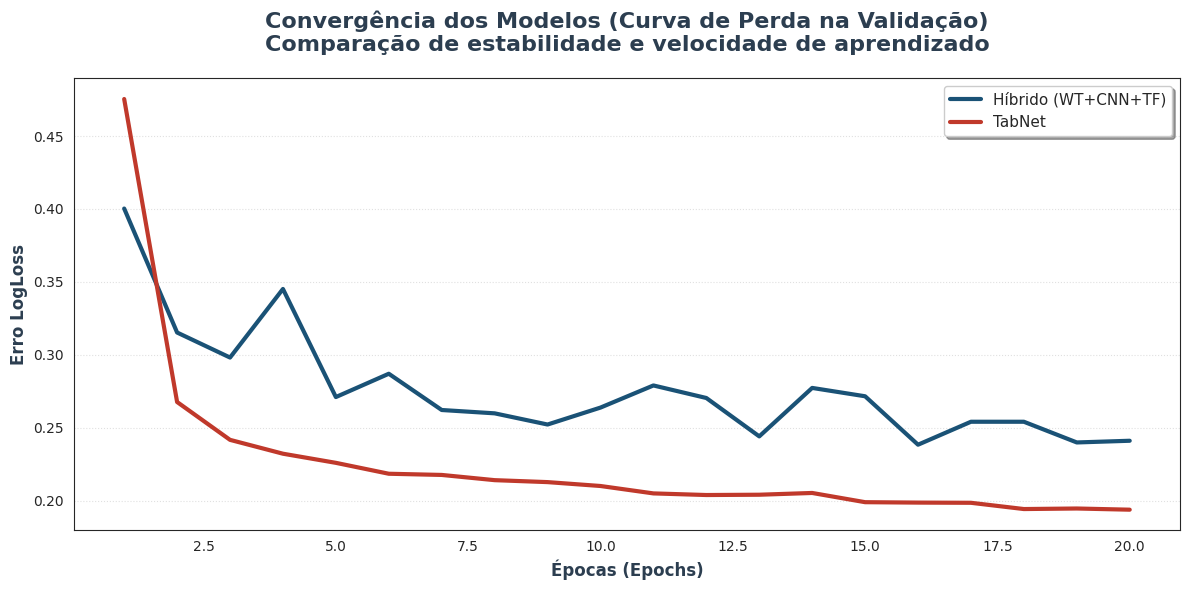

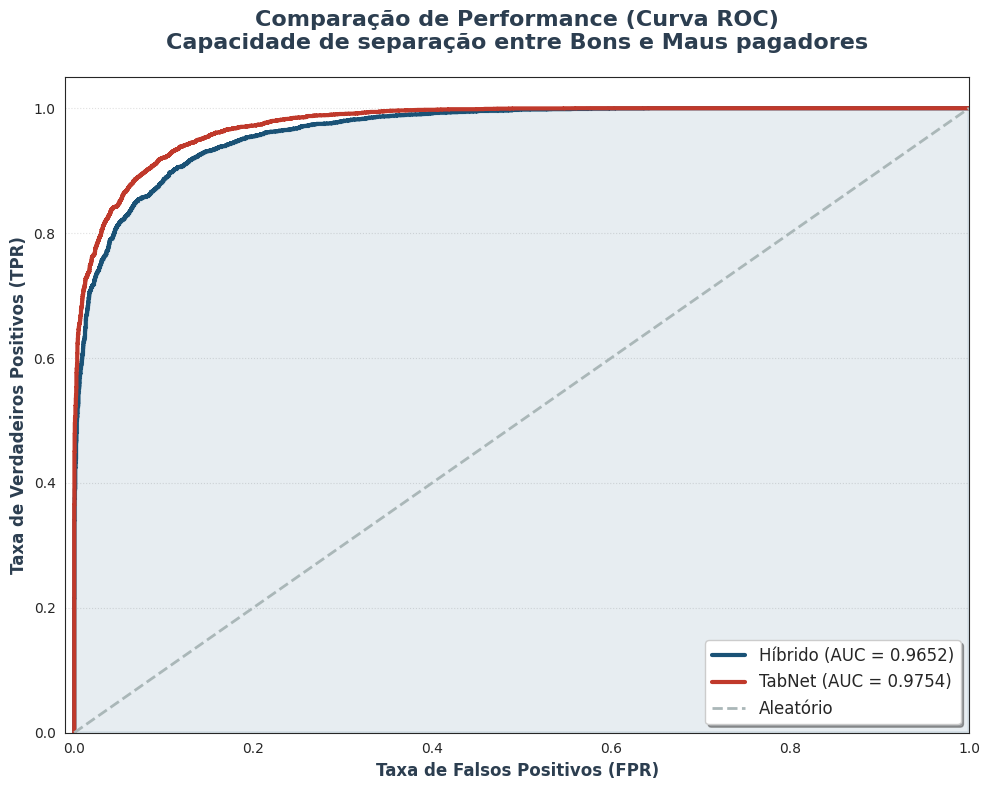

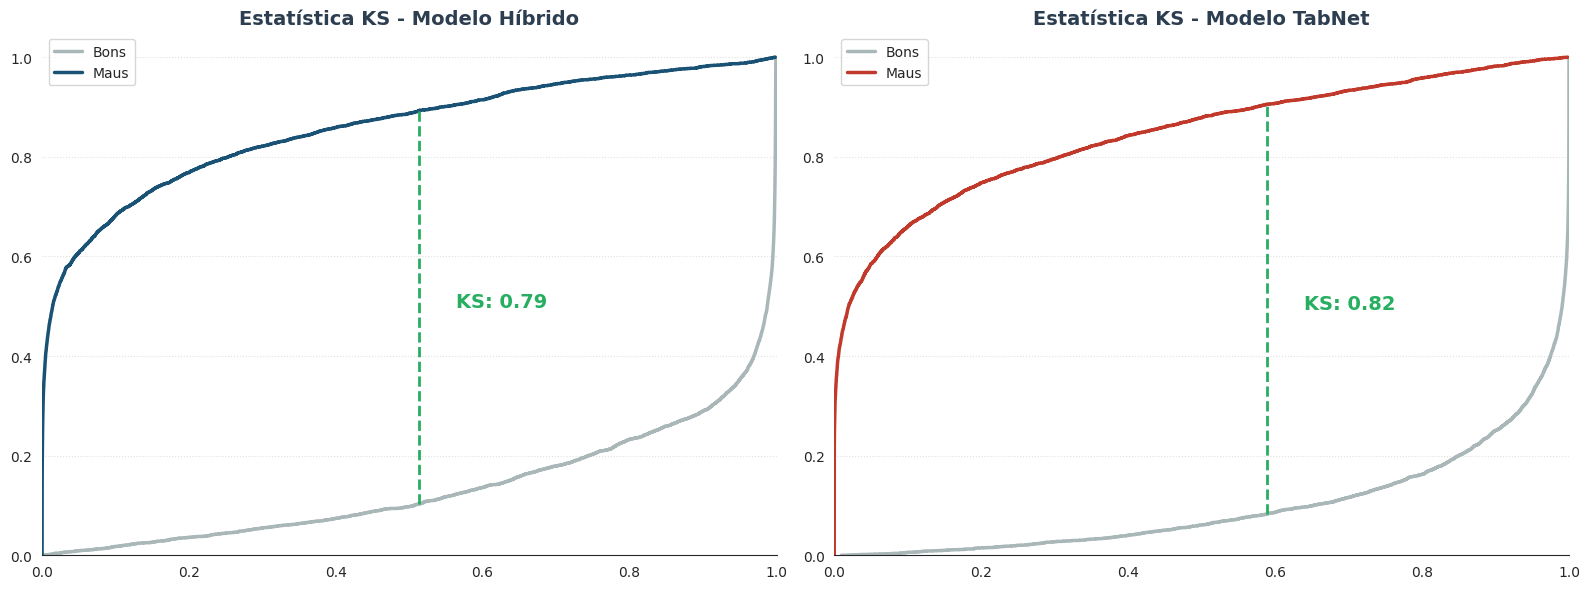

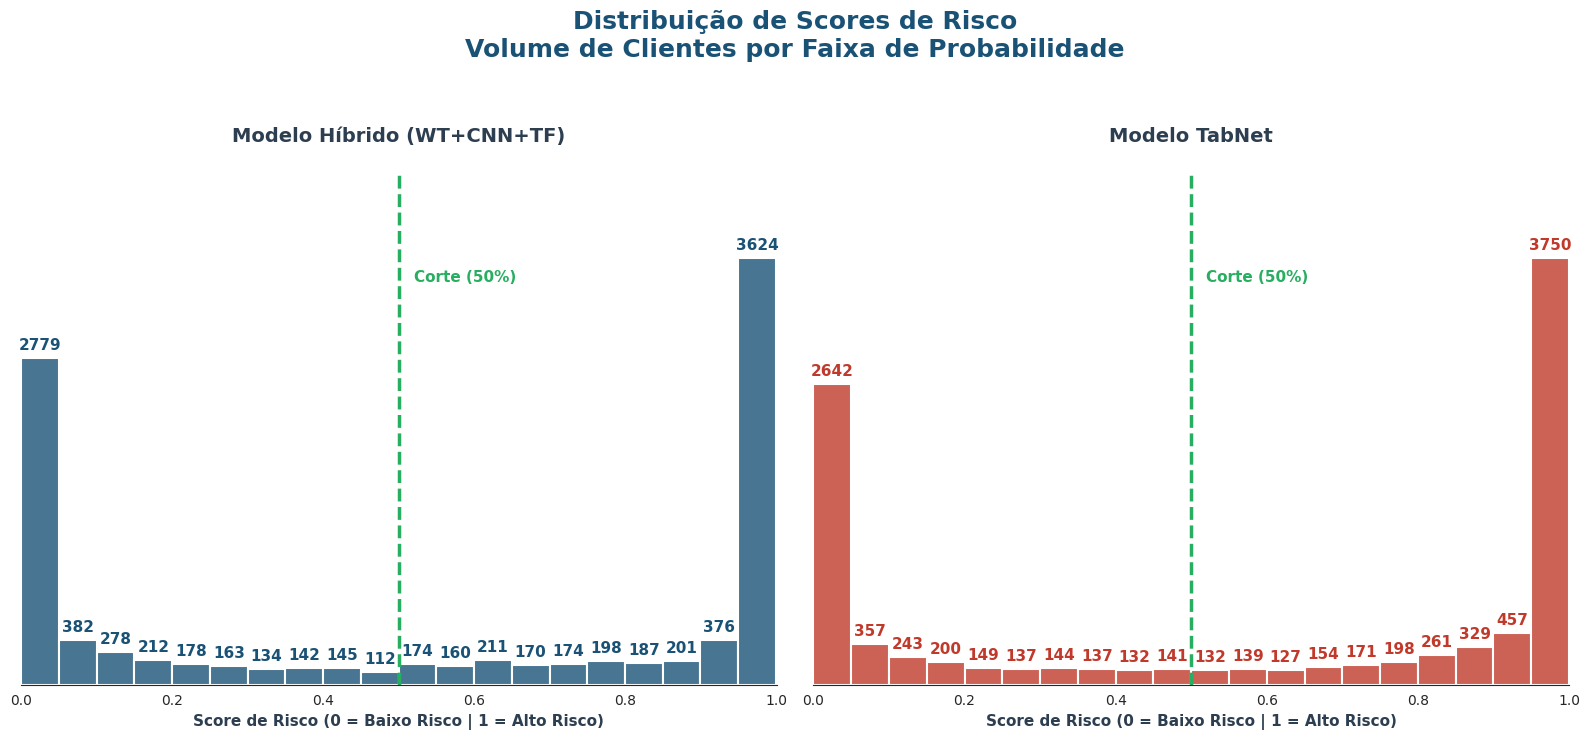

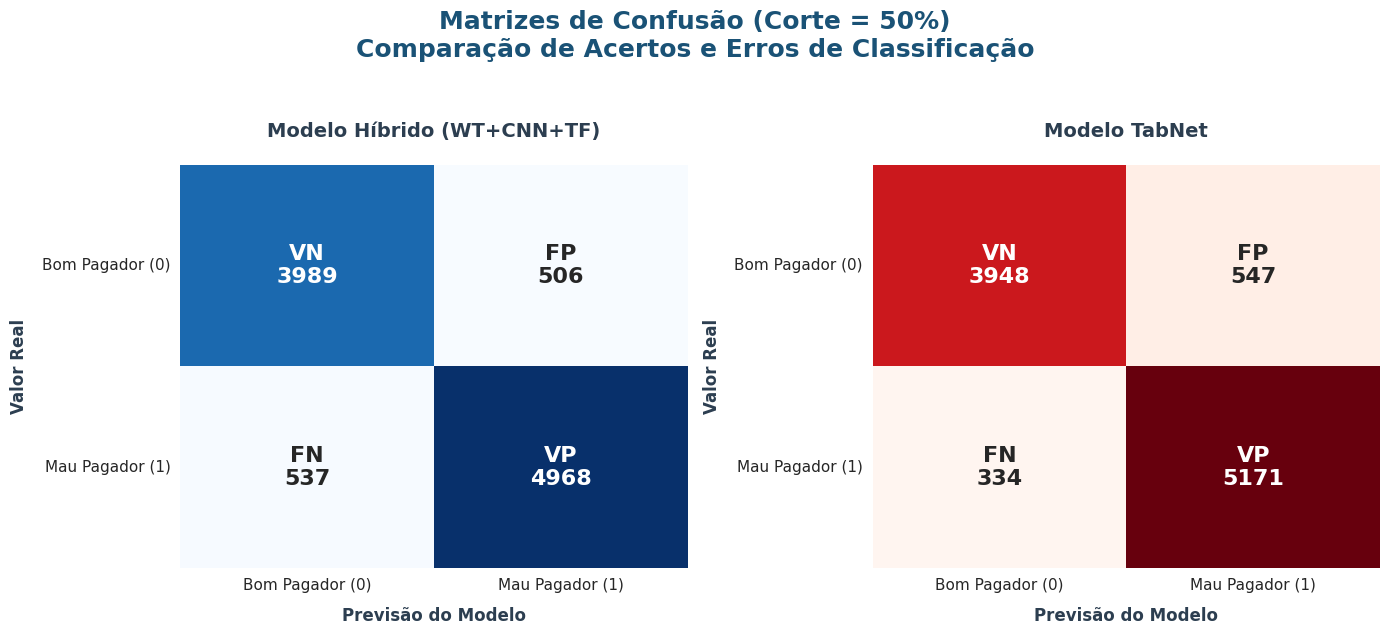

In [ ]:
print("Gerando predições e plotando gráficos...")

# ==============================================================================
# 1. PREDIÇÃO DO MODELO HÍBRIDO (WT+CNN+TF)
# ==============================================================================
# Pegamos automaticamente o nível de Wavelet (WT) que venceu o Grid Search
melhor_wt = df_resultados_wt.iloc[0]['WT']

test_dataset = WaveletLoanDataset(X_test, y_test, wavelet='db4', level=melhor_wt)
test_dl = DataLoader(test_dataset, batch_size=256, shuffle=False)

p_pred_hibrido = melhor_modelo_wt.predict_default_proba(test_dl)

# ==============================================================================
# 2. PREDIÇÃO DO TABNET
# ==============================================================================
p_pred_tabnet = model_tab_net.predict_default_proba(X_test)

# ==============================================================================
# 3. PLOTAGEM EXECUTIVA (Comparação)
# ==============================================================================
# Instanciamos a classe de visualização passando os históricos e as predições reais
visualizador = ComparadorModelos(
    history_hibrido=melhor_modelo_wt.history,
    history_tabnet=model_tab_net.model.history
    y_true=y_test,
    p_pred_hibrido=p_pred_hibrido,
    p_pred_tabnet=p_pred_tabnet
)

visualizador.plot_evolucao_loss("./plots/grafico_loss.png")
visualizador.plot_curvas_roc("./plots/grafico_roc.png")
visualizador.plot_comparacao_ks("./plots/grafico_comparacao_ks.png")
visualizador.plot_distribuicao_scores("./plots/grafico_distribuicao_scores.png")
visualizador.plot_matriz_confusao(0.5, "./plots/grafico_matriz_confusao.png")